# Space Launch Performance – Payload to Orbit

This notebook analyzes the UCS Satellite Database to visualize satellite launch trends:
- Number of satellites launched per year
- Total payload mass launched per year (in million kg)

Data source: Official UCS Satellite Database (Excel)
Last major update: ~May 2023 (7,560 satellites)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)

## 1. Load the UCS Satellite Database (Excel)

In [2]:
filename = 'UCS_Satellite_Database.xlsx'

df = pd.read_excel(filename)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
display(df.head(3))

Shape: (7560, 68)

Columns:
['Name of Satellite, Alternate Names', 'Current Official Name of Satellite', 'Country/Org of UN Registry', 'Country of Operator/Owner', 'Operator/Owner', 'Users', 'Purpose', 'Detailed Purpose', 'Class of Orbit', 'Type of Orbit', 'Longitude of GEO (degrees)', 'Perigee (km)', 'Apogee (km)', 'Eccentricity', 'Inclination (degrees)', 'Period (minutes)', 'Launch Mass (kg.)', 'Dry Mass (kg.)', 'Power (watts)', 'Date of Launch', 'Expected Lifetime (yrs.)', 'Contractor', 'Country of Contractor', 'Launch Site', 'Launch Vehicle', 'COSPAR Number', 'NORAD Number', 'Comments', 'Unnamed: 28', 'Source Used for Orbital Data', 'Source', 'Source.1', 'Source.2', 'Source.3', 'Source.4', 'Source.5', 'Source.6', 'Unnamed: 37', 'Unnamed: 38', 'Unnamed: 39', 'Unnamed: 40', 'Unnamed: 41', 'Unnamed: 42', 'Unnamed: 43', 'Unnamed: 44', 'Unnamed: 45', 'Unnamed: 46', 'Unnamed: 47', 'Unnamed: 48', 'Unnamed: 49', 'Unnamed: 50', 'Unnamed: 51', 'Unnamed: 52', 'Unnamed: 53', 'Unnamed: 54', 'Un

,"Name of Satellite, Alternate Names",Current Official Name of Satellite,Country/Org of UN Registry,Country of Operator/Owner,Operator/Owner,Users,Purpose,Detailed Purpose,Class of Orbit,Type of Orbit,...,Unnamed: 58,Unnamed: 59,Unnamed: 60,Unnamed: 61,Unnamed: 62,Unnamed: 63,Unnamed: 64,Unnamed: 65,Unnamed: 66,Unnamed: 67
0,1HOPSAT-TD (1st-generation High Optical Perfor...,1HOPSAT-TD,NR,USA,Hera Systems,Commercial,Earth Observation,Infrared Imaging,LEO,Non-Polar Inclined,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AAC AIS-Sat1 (Kelpie 1),AAC AIS-Sat1 (Kelpie 1),United Kingdom,United Kingdom,AAC Clyde Space,Commercial,Earth Observation,Automatic Identification System (AIS),LEO,Sun-Synchronous,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Aalto-1,Aalto-1,Finland,Finland,Aalto University,Civil,Technology Development,NaN,LEO,Sun-Synchronous,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Clean column names (snake_case, lowercase)

In [3]:
df.columns = (
    df.columns.str.strip()
      .str.replace(r'[^a-zA-Z0-9_\s]', '_', regex=True)
      .str.replace(r'\s+', '_', regex=True)
      .str.lower()
)

print("Cleaned columns:")
print(df.columns.tolist())

Cleaned columns:
['name_of_satellite__alternate_names', 'current_official_name_of_satellite', 'country_org_of_un_registry', 'country_of_operator_owner', 'operator_owner', 'users', 'purpose', 'detailed_purpose', 'class_of_orbit', 'type_of_orbit', 'longitude_of_geo__degrees_', 'perigee__km_', 'apogee__km_', 'eccentricity', 'inclination__degrees_', 'period__minutes_', 'launch_mass__kg__', 'dry_mass__kg__', 'power__watts_', 'date_of_launch', 'expected_lifetime__yrs__', 'contractor', 'country_of_contractor', 'launch_site', 'launch_vehicle', 'cospar_number', 'norad_number', 'comments', 'unnamed__28', 'source_used_for_orbital_data', 'source', 'source_1', 'source_2', 'source_3', 'source_4', 'source_5', 'source_6', 'unnamed__37', 'unnamed__38', 'unnamed__39', 'unnamed__40', 'unnamed__41', 'unnamed__42', 'unnamed__43', 'unnamed__44', 'unnamed__45', 'unnamed__46', 'unnamed__47', 'unnamed__48', 'unnamed__49', 'unnamed__50', 'unnamed__51', 'unnamed__52', 'unnamed__53', 'unnamed__54', 'unnamed__55',

## 3. Clean the launch mass column

In [4]:
mass_col = 'launch_mass_kg.' if 'launch_mass_kg.' in df.columns else None

if mass_col is None:
    mass_col = next((c for c in df.columns if 'launch_mass' in c or 'mass_kg' in c), None)
    print("Detected mass column:", mass_col)

if mass_col:
    df['launch_mass_clean'] = df[mass_col].astype(str).str.strip()
    df['launch_mass_clean'] = df['launch_mass_clean'].replace(
        ['-', '--', '---', 'N/A', 'n/a', '', ' '], pd.NA
    )
    df['launch_mass_clean'] = df['launch_mass_clean'].str.replace(',', '', regex=False)
    df['launch_mass_kg'] = pd.to_numeric(df['launch_mass_clean'], errors='coerce')

    df_valid_mass = df.dropna(subset=['launch_mass_kg'])
    print("Rows with valid launch mass:", len(df_valid_mass))
    print(df_valid_mass['launch_mass_kg'].describe())
else:
    print("No launch mass column found.")

Detected mass column: launch_mass__kg__


Rows with valid launch mass: 7315
count     7315.000000
mean       626.321319
std       1386.207982
min          0.500000
25%        148.000000
50%        260.000000
75%        280.000000
max      22500.000000
Name: launch_mass_kg, dtype: float64


## 4. Parse launch date → create 'year' column

In [5]:
date_col = 'date_of_launch' if 'date_of_launch' in df.columns else 'date_of_launch'

if date_col in df.columns:
    df['date_parsed'] = pd.to_datetime(df[date_col], errors='coerce')
    df['year'] = df['date_parsed'].dt.year

    print("Valid launch years:", df['year'].notna().sum())
    print("Year range:", df['year'].min(), "–", df['year'].max())
    print("\nLaunches per year (most recent 10):")
    print(df['year'].value_counts().sort_index(ascending=False).head(10))
else:
    print("No date column found. Check column names.")

Valid launch years: 7557
Year range: 1974.0 – 2023.0

Launches per year (most recent 10):


year
2023.0     909
2022.0    2113
2021.0    1590
2020.0    1054
2019.0     272
2018.0     308
2017.0     221
2016.0     107
2015.0     132
2014.0     117
Name: count, dtype: int64


## 5. Visualize satellite launch trends (count + total payload mass)

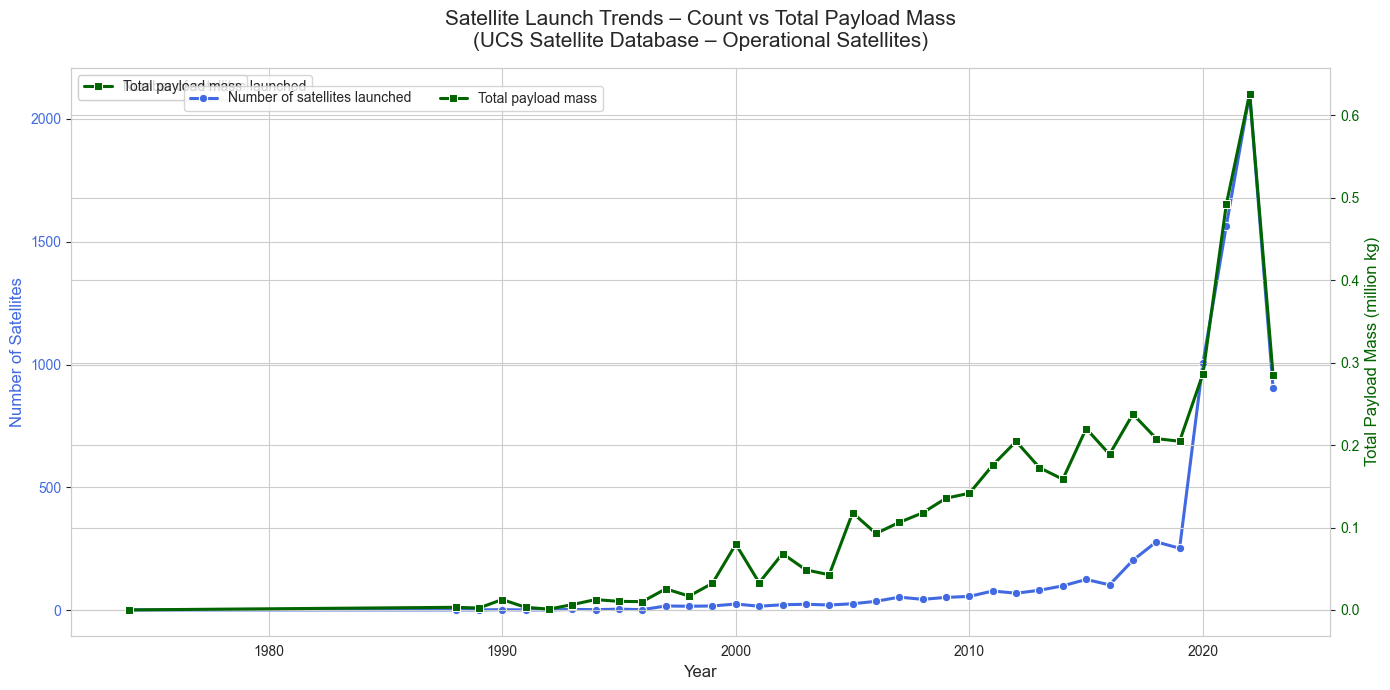

In [6]:
# Use only rows with valid year & mass
df_trends = df.dropna(subset=['year', 'launch_mass_kg'])

# Aggregations
annual_launches = df_trends.groupby('year').size()
annual_mass = df_trends.groupby('year')['launch_mass_kg'].sum() / 1_000_000  # million kg

# Plot
fig, ax1 = plt.subplots(figsize=(14, 7))

sns.lineplot(x=annual_launches.index, y=annual_launches.values,
             ax=ax1, color='royalblue', marker='o', linewidth=2.2,
             label='Number of satellites launched')
ax1.set_ylabel('Number of Satellites', color='royalblue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='royalblue')
ax1.set_xlabel('Year', fontsize=12)

ax2 = ax1.twinx()
sns.lineplot(x=annual_mass.index, y=annual_mass.values,
             ax=ax2, color='darkgreen', marker='s', linewidth=2.2,
             label='Total payload mass')
ax2.set_ylabel('Total Payload Mass (million kg)', color='darkgreen', fontsize=12)
ax2.tick_params(axis='y', labelcolor='darkgreen')

plt.title('Satellite Launch Trends – Count vs Total Payload Mass\n(UCS Satellite Database – Operational Satellites)',
          fontsize=15, pad=15)

fig.legend(loc='upper left', bbox_to_anchor=(0.13, 0.88), ncol=2, fontsize=10)
plt.tight_layout()
plt.show()

## Summary

- Sharp increase in satellite count since ~2018–2019 (mostly small LEO constellations)
- Payload mass growth is slower because many new satellites are small (~100–600 kg)
- Data ends around 2022–2023 (depending on UCS version)

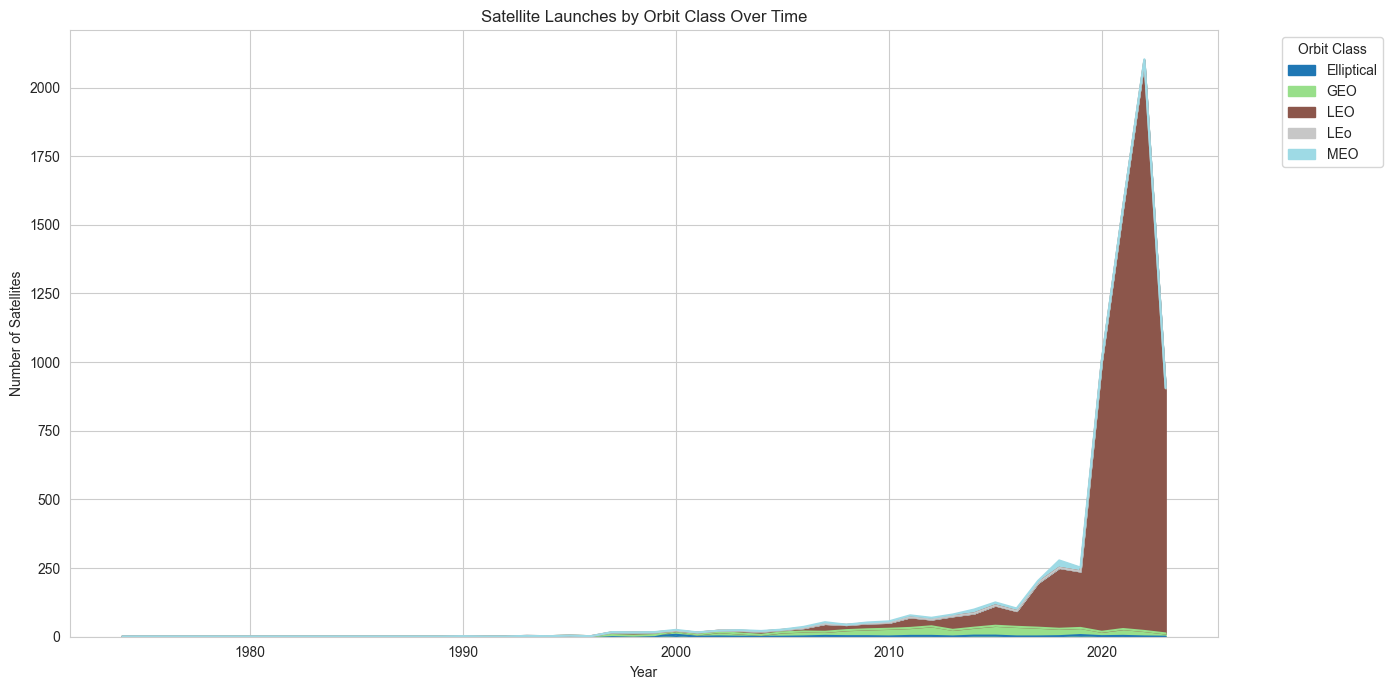

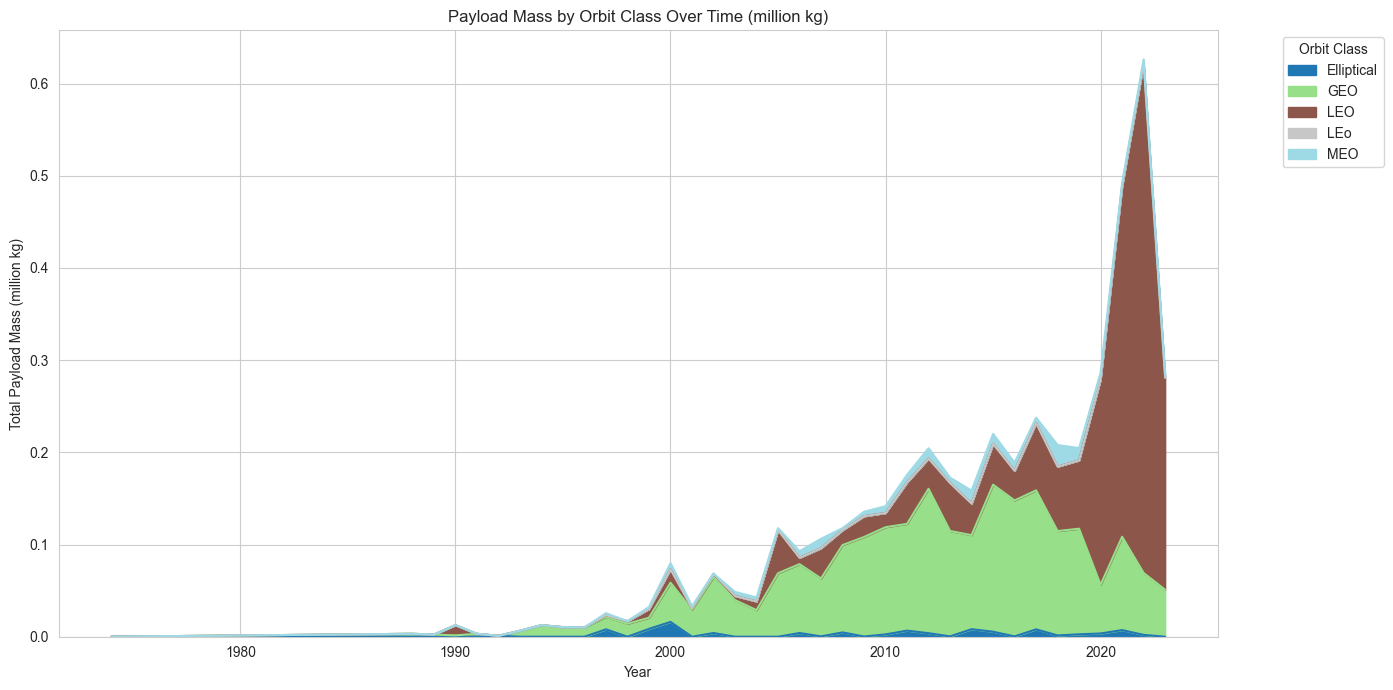

In [7]:
# Filter valid data with orbit class
df_trends = df.dropna(subset=['year', 'launch_mass_kg', 'class_of_orbit'])

# Aggregations by orbit
annual_launches_by_orbit = df_trends.groupby(['year', 'class_of_orbit']).size().unstack(fill_value=0)
annual_mass_by_orbit = df_trends.groupby(['year', 'class_of_orbit'])['launch_mass_kg'].sum().unstack(fill_value=0) / 1_000_000

# Plot stacked area for launches by orbit
annual_launches_by_orbit.plot(kind='area', stacked=True, figsize=(14, 7), colormap='tab20')
plt.title('Satellite Launches by Orbit Class Over Time')
plt.ylabel('Number of Satellites')
plt.xlabel('Year')
plt.legend(title='Orbit Class', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Plot stacked area for mass by orbit
annual_mass_by_orbit.plot(kind='area', stacked=True, figsize=(14, 7), colormap='tab20')
plt.title('Payload Mass by Orbit Class Over Time (million kg)')
plt.ylabel('Total Payload Mass (million kg)')
plt.xlabel('Year')
plt.legend(title='Orbit Class', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()